In [1]:
import torch
from torch.utils.data import DataLoader
import torchvision
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

from maskvar.models.vqvae_single import VQVAE_Single
from maskvar.datasets import MaskLevelDatasetDummy
from maskvar.models.simple_ar import (
    SimpleVAR,
    simple_var_inference,
    simple_var_train_pass
)
from maskvar.maskseg_build_everything import (
    build_hqseg44k_dataset,
    build_simple_var,
    build_vqvae_single_5_stages_v1,
    build_mobile_sam_image_encoder,
)

device = 'cuda'

In [2]:
simple_var: SimpleVAR = build_simple_var(simple_var_checkpoint_path='../out/simple_var_1_debug/checkpoints/.simple_var.200.pt', device=device)
vqvae: VQVAE_Single = build_vqvae_single_5_stages_v1('../out/out_vqvae_5_stages_v1/ckpt/vqvae_single_epoch_50.pth', require_grad=False)
vqvae = vqvae.to(device)

sam_image_encoder = build_mobile_sam_image_encoder('../ckpt/mobile_sam.pt').to(device)

In [3]:
def visualize(indices, ax, device='cpu', name='mask'):
    result = vqvae.idxBl_to_img(indices, same_shape=True)

    # for i in range(len(indices)):
    #     print(f'index {i}: {indices[i].shape}')
    # result_conv = [edge(item) for item in result]
    result = [mask for mask in result]
    chw = torchvision.utils.make_grid(torch.cat(result, dim=0), nrow=3, padding=1, pad_value=1.0)

    chw = chw.permute(1, 2, 0).cpu().numpy()
    ax.imshow(chw[:, :, 0])
    ax.axis('off')
    ax.set_title(name)

In [4]:
train_set, _ = build_hqseg44k_dataset('../data/sam-hq') # validate on train set
train_set_masklevel = MaskLevelDatasetDummy(
    dataset=train_set,
    sam_encoder=sam_image_encoder,
    with_image_embed=True,
    device=device,
    mask_filter_thresh=0.1,
    seed=42,
    count=5,
)
val_set_masklevel = MaskLevelDatasetDummy(
    dataset=train_set,
    sam_encoder=sam_image_encoder,
    with_image_embed=True,
    device=device,
    mask_filter_thresh=0.1,
    seed=42,
    count=5,
)

train_dataloader = DataLoader(train_set_masklevel, batch_size=1, shuffle=False, drop_last=True)

Loading DIS5K/DIS-VD: 100%|██████████| 464/464 [00:00<00:00, 1531201.46it/s]


In [5]:
data_iter = iter(train_dataloader)
# _ = next(data_iter)

In [6]:
image, image_embed_sam, single_mask_normalized, single_mask = next(data_iter)
print("image.shape:", image.shape)
print("image_embed_sam.shape:", image_embed_sam.shape)
print("single_mask_normalized.shape:", single_mask_normalized.shape)
print("single_mask.shape:", single_mask.shape)

image.shape: torch.Size([1, 3, 1024, 1024])
image_embed_sam.shape: torch.Size([1, 256, 64, 64])
single_mask_normalized.shape: torch.Size([1, 1, 256, 256])
single_mask.shape: torch.Size([1, 1, 256, 256])


In [7]:
# inference
id_seq = simple_var_inference(image_feat=image_embed_sam, simple_var=simple_var, vqvae=vqvae)

# gt
idx = vqvae.img_to_idxBl(single_mask_normalized)

# inference with teacher forced input
logits = simple_var_train_pass(idx, image_feat=image_embed_sam, simple_var=simple_var, vqvae=vqvae)
# sample the max token
id_seq_teach = logits.argmax(dim=-1)
id_seq_teach_Bl = []
start_pos = 0
for pn in simple_var.patch_num:
    end_pos = start_pos + pn * pn
    id_seq_teach_Bl.append(id_seq_teach[:, start_pos:end_pos])
    start_pos = end_pos

feat_down.shape: torch.Size([1, 1, 256])
feat_down.shape: torch.Size([1, 64, 256])
feat_down.shape: torch.Size([1, 256, 256])
feat_down.shape: torch.Size([1, 576, 256])
feat_down.shape: torch.Size([1, 1024, 256])
feats.shape: torch.Size([1, 1921, 256])
feat_down.shape: torch.Size([1, 1, 256])
feat_down.shape: torch.Size([1, 64, 256])
feat_down.shape: torch.Size([1, 256, 256])
feat_down.shape: torch.Size([1, 576, 256])
feat_down.shape: torch.Size([1, 1024, 256])
feats.shape: torch.Size([1, 1921, 256])


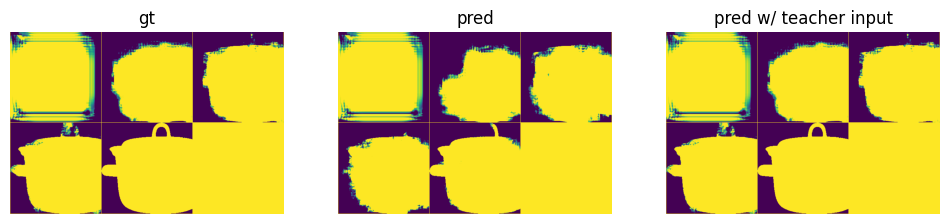

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(12,4))

visualize(idx, ax[0], name='gt')
visualize(id_seq, ax[1], name='pred')
visualize(idx, ax[2], name='pred w/ teacher input')